# Notebook 05 – Synthetic Campaign History Generation

Generate a realistic six-month customer interaction history for downstream modeling.

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta

np.random.seed(42)
customers = pd.read_csv('bank_segmented.csv')

channels = ['Phone','SMS','Email','WhatsApp']
time_slots = ['Morning','Afternoon','Evening']
start_date = pd.Timestamp('2025-01-01')
records=[]

for _, row in customers.iterrows():
    n = np.random.randint(3,8)   # 3–7 interactions/customer
    for _ in range(n):
        dt = start_date + timedelta(days=int(np.random.randint(0,180)))
        day_name = dt.day_name()

        # Simple business rules
        if row.get('persona','') == 'Retirees':
            slot = np.random.choice(time_slots,p=[0.55,0.30,0.15])
        else:
            slot = np.random.choice(time_slots,p=[0.20,0.45,0.35])

        if row.get('loan_burden',0)==2:
            channel=np.random.choice(channels,p=[0.45,0.20,0.15,0.20])
        else:
            channel=np.random.choice(channels,p=[0.30,0.25,0.20,0.25])

        connect_prob=0.35+0.20*row.get('previous_success',0)+0.10*row.get('financial_stability',0)
        connect=np.random.binomial(1,min(connect_prob,0.95))

        response_prob=0.08+0.25*connect+0.20*row.get('previous_success',0)
        responded=np.random.binomial(1,min(response_prob,0.95))

        records.append({
            'customer_id':_,
            'interaction_date':dt.date(),
            'day_of_week':day_name,
            'time_slot':slot,
            'best_time_slot':f"{day_name} {slot}",
            'channel':channel,
            'connected':connect,
            'responded':responded,
            'age':row['age'],
            'job':row['job'],
            'balance':row['balance'],
            'loan_burden':row['loan_burden'],
            'financial_stability':row['financial_stability'],
            'customer_risk_score':row['customer_risk_score'],
            'persona':row.get('persona','Unknown')
        })

history=pd.DataFrame(records)
history.head()


,customer_id,interaction_date,day_of_week,time_slot,best_time_slot,channel,connected,responded,age,job,balance,loan_burden,financial_stability,customer_risk_score,persona
0,0,2025-04-03,Thursday,Morning,Thursday Morning,WhatsApp,1,0,58,management,2143,1,0.66146,1,Retirees
1,1,2025-03-16,Sunday,Morning,Sunday Morning,SMS,0,0,58,management,2143,1,0.66146,1,Retirees
2,2,2025-02-22,Saturday,Evening,Saturday Evening,WhatsApp,0,0,58,management,2143,1,0.66146,1,Retirees
3,3,2025-01-21,Tuesday,Afternoon,Tuesday Afternoon,Email,0,0,58,management,2143,1,0.66146,1,Retirees
4,4,2025-02-28,Friday,Morning,Friday Morning,Phone,1,0,58,management,2143,1,0.66146,1,Retirees


In [2]:
print(history.shape)
print(history['responded'].value_counts(normalize=True))
print(history['channel'].value_counts())
print(history['best_time_slot'].value_counts().head())

(225985, 15)
responded
0    0.810983
1    0.189017
Name: proportion, dtype: float64
channel
Phone       71234
SMS         55370
WhatsApp    55259
Email       44122
Name: count, dtype: int64
best_time_slot
Saturday Morning     12893
Wednesday Morning    12872
Friday Morning       12868
Thursday Morning     12719
Sunday Morning       12546
Name: count, dtype: int64


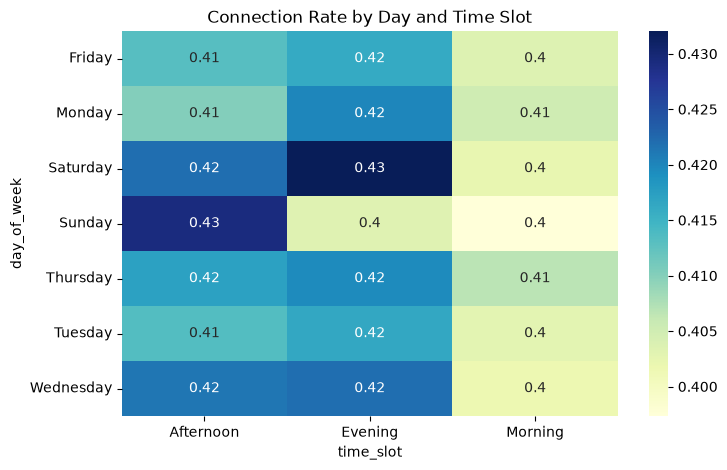

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot=history.pivot_table(index='day_of_week',
                          columns='time_slot',
                          values='connected',
                          aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot,annot=True,cmap='YlGnBu')
plt.title('Connection Rate by Day and Time Slot')
plt.show()

In [4]:
channel_cost={'Phone':10,'SMS':0.30,'Email':0.05,'WhatsApp':0.60}
history['channel_cost']=history['channel'].map(channel_cost)

history.to_csv('synthetic_campaign_history.csv',index=False)
print('Saved synthetic_campaign_history.csv')

Saved synthetic_campaign_history.csv


## Business Notes

- Each customer receives 3–7 simulated interactions over six months.
- Interaction probabilities depend on customer profile and previous campaign success.
- The generated dataset will support:
  - Best Time-to-Call Modeling
  - Channel Affinity Modeling
  - Response Propensity Modeling
  - Campaign Optimization
